In [5]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

/Users/Khalid.Talakshi/Documents/research-projects/grid-position/.venv/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [6]:
data = pd.read_csv("../data/grid-results.csv")
circuit_types = pd.read_csv("../data/circuit-type.csv")
data["GridPosition"] = data["GridPosition"].astype("int")
data["ClassifiedPosition"] = data["ClassifiedPosition"].astype("int")
data["circuitType"] = data["circuitId"].map(circuit_types.set_index("circuitId")["trackType"])
data["IsStreetCircuit"] = (data["circuitType"] == "street").astype("int")
data["IsGroundEffect"] = (data["year"] >= 2022).astype("int")
data[["GridPosition", "ClassifiedPosition", "IsStreetCircuit", "IsGroundEffect"]]

,GridPosition,ClassifiedPosition,IsStreetCircuit,IsGroundEffect
0,3,1,1,0
1,1,2,1,0
2,2,3,1,0
3,8,4,1,0
4,10,5,1,0
...,...,...,...,...
1980,11,12,0,1
1981,12,13,0,1
1982,10,14,0,1
1983,14,15,0,1


In [7]:
grid_mean = data["GridPosition"].mean()
grid_std = data["GridPosition"].std()
grid_z = (data["GridPosition"] - grid_mean) / grid_std
grid_z

finishing_position = data["ClassifiedPosition"]
finish_idx = finishing_position - 1
finish_idx

0        0
1        1
2        2
3        3
4        4
        ..
1980    11
1981    12
1982    13
1983    14
1984    15
Name: ClassifiedPosition, Length: 1985, dtype: int64

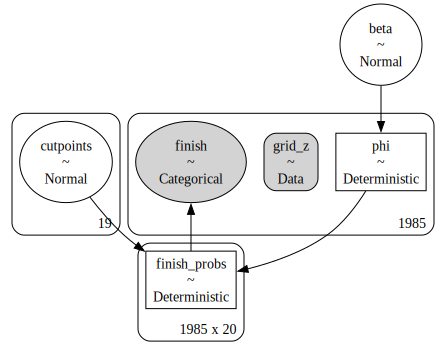

In [8]:
K = int(finish_idx.max()) + 1

with pm.Model() as model:
    # data
    pm.Data("grid_z", grid_z)

    # priors
    beta = pm.Normal("beta", mu=0, sigma=1)
    cutpoints = pm.Normal(
        "cutpoints",
        mu=np.linspace(-2, 2, K - 1),
        sigma=1.5,
        transform=pm.distributions.transforms.ordered,
        initval=np.linspace(-2, 2, K - 1),
        shape=K - 1,
    )

    # Linear Predictor
    phi = pm.Deterministic("phi", beta * grid_z)

    # Likelihood
    finish = pm.OrderedLogistic("finish", eta=phi, cutpoints=cutpoints, observed=finish_idx)

pm.model_to_graphviz(model)

In [ ]:
N_DRAWS = 2000
N_TUNES = 1000
N_CHAINS = 4
N_TARGET_ACCEPT = 0.95
SEED = 39

with model:
    trace = pm.sample(
        draws=N_DRAWS,
        tune=N_TUNES,
        chains=N_CHAINS,
        target_accept=N_TARGET_ACCEPT,
        random_seed=SEED,
    )
    pm.sample_posterior_predictive(trace, extend_inferencedata=True, var_names=["finish"], random_seed=SEED)
az.plot_trace(trace, var_names=["beta", "cutpoints"])
plt.show()

In [10]:
grid_positions = np.arange(1, 21)

posterior = trace.posterior
beta_samples = posterior["beta"].values.flatten()          # (draws,)
cutpoints_samples = posterior["cutpoints"].values.reshape(-1, posterior["cutpoints"].shape[-1])  # (draws, K-1)

K = cutpoints_samples.shape[1] + 1
records = []

for gp in grid_positions:
    gp_z = (gp - grid_mean) / grid_std
    eta = beta_samples * gp_z    # (draws,)

    # Cumulative probabilities via logistic CDF
    # P(finish <= k) = logistic(cutpoints[k] - eta)
    cum_probs = 1.0 / (1.0 + np.exp(-(cutpoints_samples - eta[:, None])))  # (draws, K-1)

    # Cell probabilities: P(finish = k) = P(finish<=k) - P(finish<=k-1)
    # Prepend 0 and append 1 for boundary conditions
    zeros = np.zeros((cum_probs.shape[0], 1))
    ones  = np.ones((cum_probs.shape[0], 1))
    cum_full = np.hstack([zeros, cum_probs, ones])           # (draws, K+1)
    cell_probs = np.diff(cum_full, axis=1)                    # (draws, K)

    mean_probs = cell_probs.mean(axis=0)                      # (K,)

    for k, prob in enumerate(mean_probs):
        records.append({
            "grid_position": int(gp),
            "finish_position": k + 1,     # back to 1-indexed
            "probability": float(prob),
        })
results_df = pd.DataFrame.from_records(records)
results_df

,grid_position,finish_position,probability
0,1,1,0.291045
1,1,2,0.236280
2,1,3,0.172430
3,1,4,0.114271
4,1,5,0.071135
...,...,...,...
395,20,16,0.141397
396,20,17,0.134366
397,20,18,0.061333
398,20,19,0.034590


In [11]:
summary = az.summary(trace , var_names=["beta", "cutpoints"], round_to=3)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,1.949,0.056,1.846,2.060,0.001,0.001,6241.087,6517.466,1.000
cutpoints[0],-3.518,0.095,-3.697,-3.339,0.001,0.001,4752.195,5816.343,1.001
cutpoints[1],-2.517,0.074,-2.655,-2.373,0.001,0.001,6762.861,6336.988,1.001
cutpoints[2],-1.779,0.065,-1.898,-1.655,0.001,0.001,7467.458,6934.335,1.000
cutpoints[3],-1.148,0.061,-1.261,-1.031,0.001,0.001,8148.718,6545.623,1.000
cutpoints[4],-0.581,0.056,-0.688,-0.477,0.001,0.001,8720.810,6557.752,1.000
cutpoints[5],-0.043,0.055,-0.145,0.060,0.001,0.001,9272.806,6808.499,1.000
cutpoints[6],0.484,0.057,0.380,0.594,0.001,0.001,8769.727,7220.734,1.000
cutpoints[7],1.006,0.060,0.895,1.121,0.001,0.001,9237.960,7267.751,1.000
cutpoints[8],1.505,0.065,1.385,1.630,0.001,0.001,8870.579,6866.573,1.000


In [12]:
trace.to_netcdf("basic-model-v1.nc")

'basic-model-v1.nc'

In [31]:
"""
Devosfera Matplotlib Theme
Provides utilities for applying the Devosfera theme to Matplotlib plots
"""

import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
from typing import Optional, List, Union

# Color palette
COLORS = {
    'primary': {
        'blue': '#3b82f6',
        'blue_bright': '#60a5fa',
        'purple': '#a855f7',
    },
    'neutral': {
        'white': '#ffffff',
        'light_gray': '#f5f5f5',
        'gray': '#888888',
        'dark_gray': '#333333',
        'background': '#111111',
        'surface': '#1a1a1a',
        'muted': '#1f1f1f',
    },
    'chart': [
        '#3b82f6',
        '#a855f7',
        '#60a5fa',
        '#ec4899',
        '#f59e0b',
        '#10b981',
        '#06b6d4',
        '#8b5cf6',
    ],
}


def apply_theme(
    style: str = 'dark',
    color_scale: Optional[str] = None,
    colors: Optional[List[str]] = None,
) -> None:
    """
    Apply the Devosfera theme to Matplotlib

    Args:
        style: Theme style ('dark' is currently supported)
        color_scale: Predefined color scale ('ordinal', 'sequential', 'diverging')
        colors: Custom list of colors to use

    Example:
        >>> apply_theme()
        >>> plt.plot([1, 2, 3], [1, 4, 9])
        >>> plt.show()
    """
    # Load the style file
    style_path = Path(Path.cwd()).parent / 'devosfera.mplstyle'
    if style_path.exists():
        plt.style.use(str(style_path))
    else:
        # Fallback to manual configuration
        _apply_manual_theme()

    # Apply custom colors if provided
    if colors:
        _set_colors(colors)
    elif color_scale:
        _apply_color_scale(color_scale)


def _apply_manual_theme() -> None:
    """Apply theme settings manually"""
    mpl.rcParams['figure.facecolor'] = COLORS['neutral']['background']
    mpl.rcParams['figure.edgecolor'] = COLORS['neutral']['dark_gray']
    mpl.rcParams['axes.facecolor'] = COLORS['neutral']['background']
    mpl.rcParams['axes.edgecolor'] = COLORS['neutral']['dark_gray']
    mpl.rcParams['axes.labelcolor'] = COLORS['neutral']['light_gray']
    mpl.rcParams['text.color'] = COLORS['neutral']['light_gray']
    mpl.rcParams['xtick.color'] = COLORS['neutral']['gray']
    mpl.rcParams['ytick.color'] = COLORS['neutral']['gray']
    mpl.rcParams['grid.color'] = COLORS['neutral']['dark_gray']
    mpl.rcParams['legend.facecolor'] = COLORS['neutral']['surface']
    mpl.rcParams['legend.edgecolor'] = COLORS['neutral']['dark_gray']
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(
        'color', COLORS['chart']
    )


def _set_colors(colors: List[str]) -> None:
    """Set custom colors"""
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler('color', colors)


def _apply_color_scale(scale: str) -> None:
    """Apply a predefined color scale"""
    scales = {
        'ordinal': COLORS['chart'],
        'sequential': [
            '#3b82f6',
            '#2563eb',
            '#1d4ed8',
            '#1e40af',
            '#1e3a8a',
        ],
        'diverging': [
            '#ec4899',
            '#f472b6',
            '#f5f5f5',
            '#60a5fa',
            '#3b82f6',
        ],
    }

    if scale in scales:
        _set_colors(scales[scale])


def get_colors(
    scale: str = 'ordinal',
    custom: Optional[List[str]] = None,
) -> List[str]:
    """
    Get a list of colors

    Args:
        scale: Color scale ('ordinal', 'sequential', 'diverging')
        custom: Custom colors to use instead

    Returns:
        List of hex color codes
    """
    if custom:
        return custom

    scales = {
        'ordinal': COLORS['chart'],
        'sequential': [
            '#3b82f6',
            '#2563eb',
            '#1d4ed8',
            '#1e40af',
            '#1e3a8a',
        ],
        'diverging': [
            '#ec4899',
            '#f472b6',
            '#f5f5f5',
            '#60a5fa',
            '#3b82f6',
        ],
    }

    return scales.get(scale, COLORS['chart'])


def get_color(index: int, scale: str = 'ordinal') -> str:
    """
    Get a specific color

    Args:
        index: Color index
        scale: Color scale

    Returns:
        Hex color code
    """
    colors = get_colors(scale)
    return colors[index % len(colors)]


def get_palette() -> dict:
    """Get the complete color palette"""
    return COLORS


def reset_theme() -> None:
    """Reset to Matplotlib defaults"""
    mpl.rcdefaults()

In [30]:
import os
from pathlib import Path
Path(Path.cwd()).parent / "devosfera.mplstyle"

PosixPath('/Users/Khalid.Talakshi/Documents/research-projects/grid-position/devosfera.mplstyle')

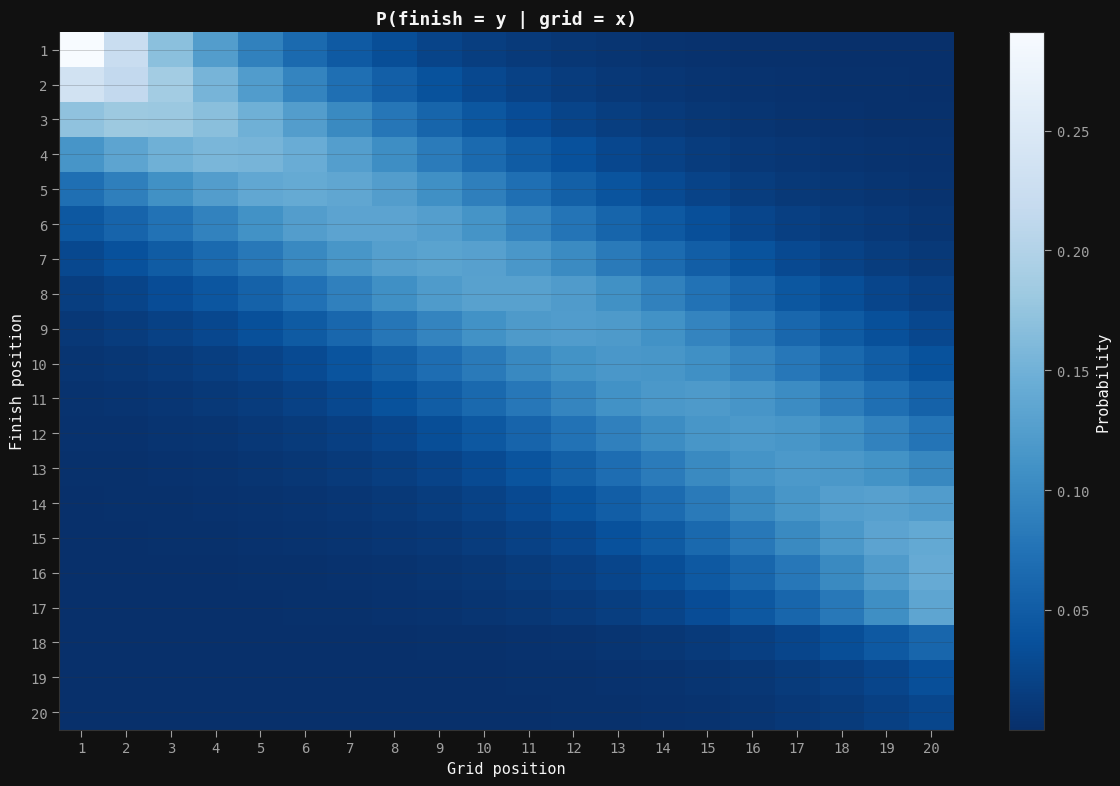

In [34]:
    pivot = results_df.pivot(
        index="finish_position", columns="grid_position", values="probability"
    )

    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(pivot.values, aspect="auto", cmap="Blues_r", origin="upper")

    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(pivot.shape[0]))
    ax.set_yticklabels(pivot.index)

    ax.set_xlabel("Grid position")
    ax.set_ylabel("Finish position")
    ax.set_title("P(finish = y | grid = x)")

    plt.colorbar(im, ax=ax, label="Probability")
    plt.tight_layout()
    apply_theme()